#### Importing Libraries

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

#### Reading Data

In [2]:
df=pd.read_csv("laptop_data.csv")

#### Displaying a Sample of the Data

In [3]:
df.head()

,Age,Gender,Salary,BuyLaptop
0,22.0,Male,50000.0,No
1,5.0,Female,65000.0,Yes
2,26.0,Male,1000000.0,No
3,40.0,Female,72000.0,Yes
4,30.0,Male,61000.0,No


#### Data Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        46 non-null     float64
 1   Gender     52 non-null     object 
 2   Salary     45 non-null     float64
 3   BuyLaptop  52 non-null     object 
dtypes: float64(2), object(2)
memory usage: 1.8+ KB


#### Statistical Description

In [5]:
df.describe()

,Age,Salary
count,46.000000,45.000000
mean,36.782609,202259.644444
std,27.465464,331002.321347
min,5.000000,50000.000000
25%,24.000000,54000.000000
50%,27.000000,62000.000000
75%,38.000000,80000.000000
max,120.000000,1000000.000000


#### Displaying the Data

<function matplotlib.pyplot.show(close=None, block=None)>

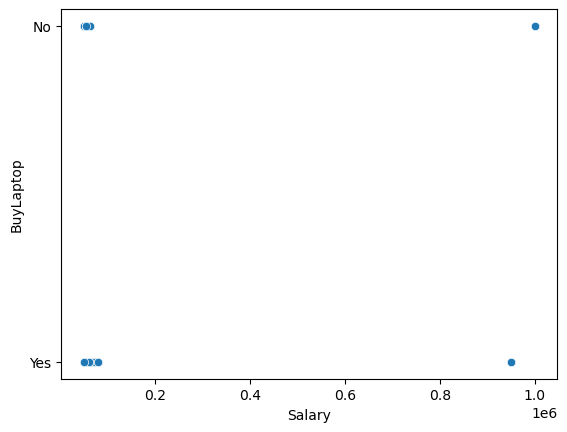

In [6]:
sns.scatterplot(x=df['Salary'],y=df['BuyLaptop'])
plt.show

### Null

In [7]:
df['Age'].fillna(df['Age'].median(),inplace=True)

C:\Users\Raidan\AppData\Local\Temp\ipykernel_7140\1527141296.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(),inplace=True)


In [8]:
df=df[df['Age']<70]
df=df[df['Salary']<500000]

In [9]:
df.isnull().sum()



Age          0
Gender       0
Salary       0
BuyLaptop    0
dtype: int64

#### Displaying the Data

<function matplotlib.pyplot.show(close=None, block=None)>

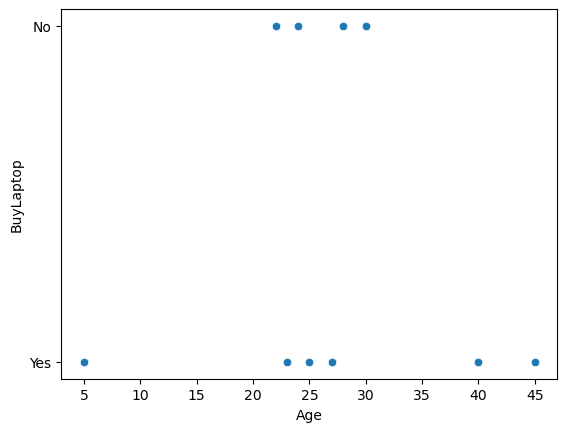

In [10]:
sns.scatterplot(x=df['Age'],y=df['BuyLaptop'])
plt.show

#### Independent and Dependent Variables

In [11]:
df.columns

Index(['Age', 'Gender', 'Salary', 'BuyLaptop'], dtype='object')

In [12]:
X=df[['Age', 'Gender', 'Salary']]
Y=df['BuyLaptop']


#### Encoding data

In [13]:
le_gender=LabelEncoder()
X['Gender']=le_gender.fit_transform(X['Gender'])

le_target=LabelEncoder()
Y_encoded=le_target.fit_transform(Y)

C:\Users\Raidan\AppData\Local\Temp\ipykernel_7140\966329666.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Gender']=le_gender.fit_transform(X['Gender'])


#### Data Splitting

In [14]:
x_train,x_test,y_train,y_test=train_test_split(X,Y_encoded,test_size=0.2,random_state=1)

#### Building the Model


In [15]:
model=DecisionTreeClassifier(max_depth=3,random_state=1)
model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=1)

#### Predicting Test Values

In [16]:
y_hat=model.predict(x_test)

In [17]:
y_hat

array([1, 0, 0, 1, 0, 1, 0, 1])

In [18]:
y_test

array([1, 1, 0, 1, 0, 1, 1, 1])

#### Performance Evaluation


In [19]:
accuracy_score(y_test,y_hat)


0.75

#### Predicting New Values

In [23]:
new=pd.DataFrame({"Age":[25],"Gender":["Male"],"Salary":[65000],})
new['Gender']=le_gender.fit_transform(new['Gender'])
pre=model.predict(new)
print(le_target.inverse_transform(pre))

['Yes']


#### Displaying The Tree

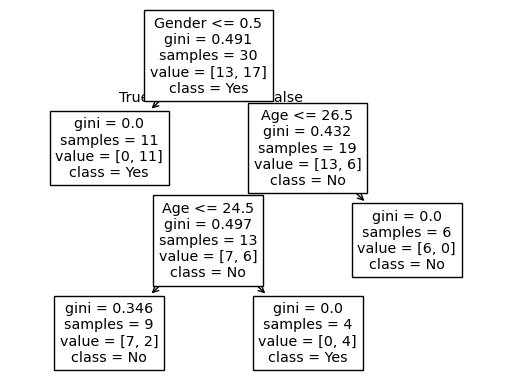

In [24]:
plot_tree(model,feature_names=X.columns,class_names=le_target.classes_)
plt.show()